In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import torch
from torch.utils.data import Dataset, DataLoader
from torch.export import export


In [18]:
normal_df = pd.read_csv('../dataset/clean/normal_dataset.csv')
attack_df = pd.read_csv('../dataset/clean/attack_dataset.csv')

In [19]:
dataset = pd.concat([normal_df,attack_df],ignore_index=True)

In [20]:
# Separate features and labels
X = dataset.drop(columns=["label"]).values
y = dataset["label"].values

In [21]:
# ==========================================
# Step 2 — Keep -1 mask BEFORE normalization
# ==========================================
mask = (X == -1)   # True where feature value is -1 (unused)

In [22]:


def create_sliding_windows(X, y, window_size=10):
    X_seq = []
    y_seq = []

    for i in range(len(X) - window_size):
        X_seq.append(X[i : i + window_size])     # 10 rows
        y_seq.append(y[i + window_size])         # label of next row

    return np.array(X_seq), np.array(y_seq)

In [23]:
# X has shape [N, features], y has shape [N]

X_seq, y_seq = create_sliding_windows(X, y, window_size=20)
print("Sliding window X shape:", X_seq.shape)
print("Sliding window y shape:", y_seq.shape)

Sliding window X shape: (7331, 20, 1408)
Sliding window y shape: (7331,)


In [24]:
# ==========================================
# Step 3 — Train/Test split
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq,
    test_size=0.2,
    random_state=42,
    stratify=y_seq
)



In [25]:
# ==========================================
# Step 4 — Normalize to range (-1, 1)
# ==========================================
scaler = MinMaxScaler(feature_range=(0, 1))

# Flatten only training data
X_train_2d = X_train.reshape(-1, X_train.shape[2])
X_test_2d  = X_test.reshape(-1, X_test.shape[2])

# Fit only on training data
X_train_2d_scaled = scaler.fit_transform(X_train_2d)
X_test_2d_scaled  = scaler.transform(X_test_2d)

# Restore unused markers (-1)
#X_train_2d_scaled[X_train_2d == -1] = -1
#X_test_2d_scaled[X_test_2d == -1] = -1

# Reshape back into sequences
X_train_scaled = X_train_2d_scaled.reshape(X_train.shape[0], 20, X_train.shape[2])
X_test_scaled  = X_test_2d_scaled.reshape(X_test.shape[0], 20, X_test.shape[2])

In [26]:
# ==========================================
# Step 5 — PyTorch Dataset
# ==========================================
class SlidingWindowDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = SlidingWindowDataset(X_train_scaled, y_train)
test_dataset  = SlidingWindowDataset(X_test_scaled, y_test)

In [27]:
# ==========================================
# Step 6 — DataLoaders
# ==========================================
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)


print("Dataset ready!")
print("Train samples:", X_train_scaled.shape)
print("Test samples :", X_test_scaled.shape)

Dataset ready!
Train samples: (5864, 20, 1408)
Test samples : (1467, 20, 1408)


In [28]:
dataset.describe()

,e212_gummei_mcc_show,e212_gummei_mcc_value,e212_gummei_mcc_size,e212_gummei_mcc_pos,e212_gummei_mnc_show,e212_gummei_mnc_value,e212_gummei_mnc_size,e212_gummei_mnc_pos,e212_imsi_show,e212_imsi_value,...,nr-rrc_ul_ccch_message_message_pos,nr-rrc_ul_dcch_message_message_show,nr-rrc_ul_dcch_message_message_value,nr-rrc_ul_dcch_message_message_size,nr-rrc_ul_dcch_message_message_pos,nr-rrc_valuetag_show,nr-rrc_valuetag_value,nr-rrc_valuetag_size,nr-rrc_valuetag_pos,label
count,7351.000000,7351.000000,7351.000000,7351.000000,7351.000000,7351.000000,7351.000000,7351.000000,7.351000e+03,7351.000000,...,7351.0,7351.0,7351.0,7351.0,7351.0,7351.0,7351.0,7351.0,7351.0,7351.000000
mean,-0.942321,5.979187,-0.913481,0.894028,-0.942321,1778.779078,-0.913481,0.922868,3.532344e+10,-0.882786,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.888587
std,0.334734,40.502806,0.502101,11.964747,0.334734,10328.717505,0.502101,12.118683,1.855973e+11,0.623363,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.314665
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000e+00,-1.000000,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,0.000000
25%,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000e+00,-1.000000,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.000000
50%,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000e+00,-1.000000,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.000000
75%,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000e+00,-1.000000,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.000000
max,1.000000,241.000000,2.000000,153.000000,1.000000,61712.000000,2.000000,154.000000,1.011235e+12,3.155639,...,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,1.000000


Epoch 1/40 | Loss: 0.2158 | Val Loss: 0.0687 | Acc: 0.9714 | Prec: 0.9738 | Rec: 0.9946 | F1: 0.9841 | FPR: 0.2188 | AUC: 0.9941


Epoch 2/40 | Loss: 0.0565 | Val Loss: 0.0298 | Acc: 0.9911 | Prec: 0.9916 | Rec: 0.9985 | F1: 0.9950 | FPR: 0.0688 | AUC: 0.9988


Epoch 3/40 | Loss: 0.0244 | Val Loss: 0.0162 | Acc: 0.9939 | Prec: 0.9947 | Rec: 0.9985 | F1: 0.9966 | FPR: 0.0437 | AUC: 0.9997


Epoch 4/40 | Loss: 0.0078 | Val Loss: 0.0229 | Acc: 0.9952 | Prec: 0.9962 | Rec: 0.9985 | F1: 0.9973 | FPR: 0.0312 | AUC: 0.9991


Epoch 5/40 | Loss: 0.0089 | Val Loss: 0.0054 | Acc: 0.9986 | Prec: 1.0000 | Rec: 0.9985 | F1: 0.9992 | FPR: 0.0000 | AUC: 1.0000


...

Epoch 36/40 | Loss: 0.0006 | Val Loss: 0.0007 | Acc: 0.9993 | Prec: 0.9992 | Rec: 1.0000 | F1: 0.9996 | FPR: 0.0063 | AUC: 1.0000


Epoch 37/40 | Loss: 0.0005 | Val Loss: 0.0006 | Acc: 0.9993 | Prec: 0.9992 | Rec: 1.0000 | F1: 0.9996 | FPR: 0.0063 | AUC: 1.0000


Epoch 38/40 | Loss: 0.0008 | Val Loss: 0.0002 | Acc: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000 | FPR: 0.0000 | AUC: 1.0000


Epoch 39/40 | Loss: 0.0003 | Val Loss: 0.0001 | Acc: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000 | FPR: 0.0000 | AUC: 1.0000


Epoch 40/40 | Loss: 0.0002 | Val Loss: 0.0003 | Acc: 1.0000 | Prec: 1.0000 | Rec: 1.0000 | F1: 1.0000 | FPR: 0.0000 | AUC: 1.0000


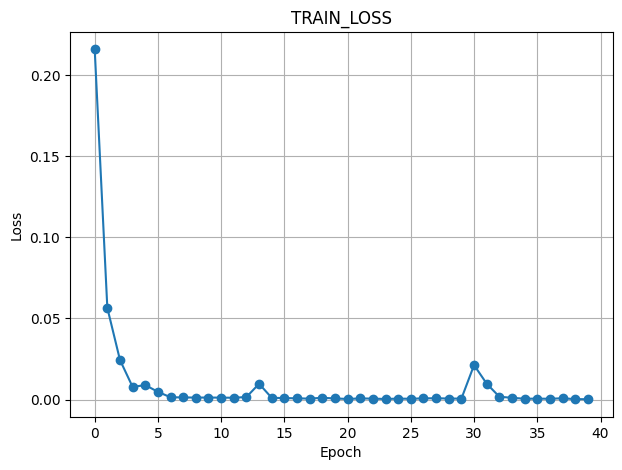

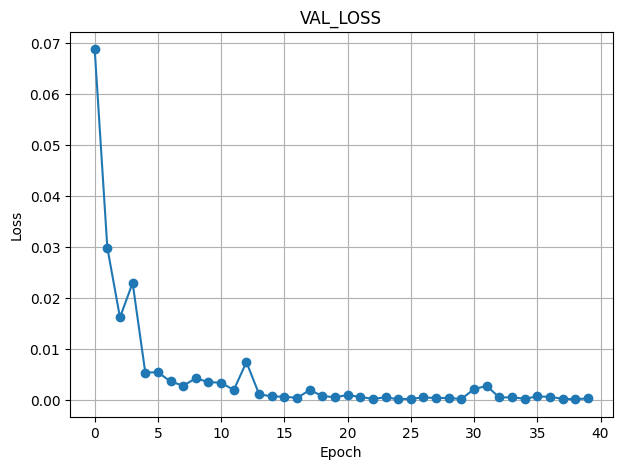

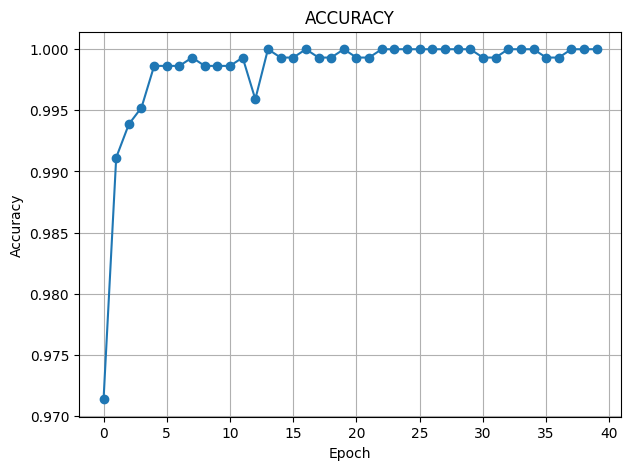

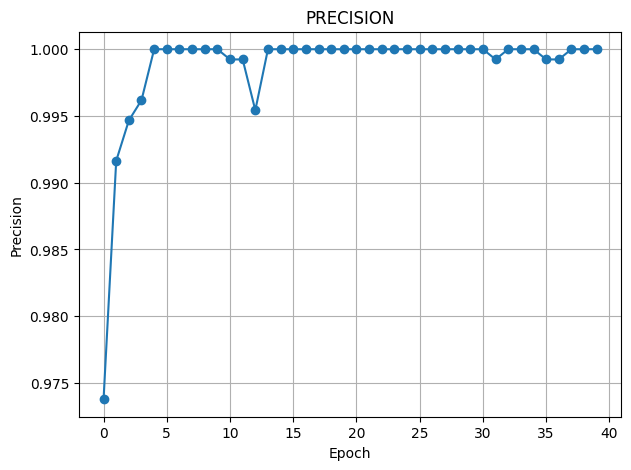

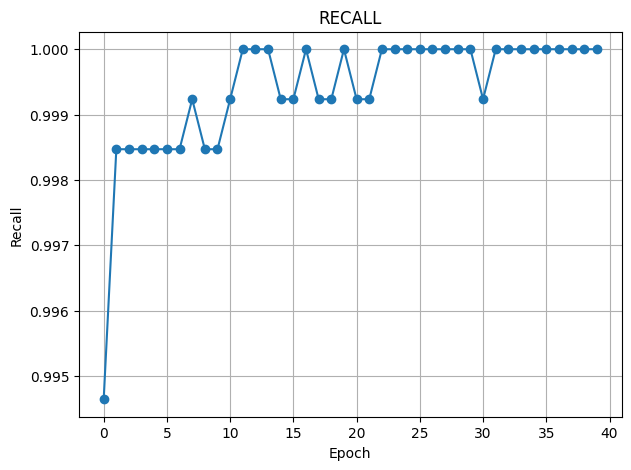

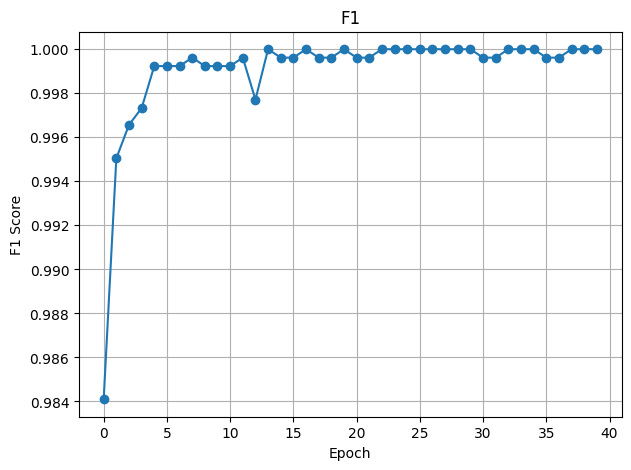

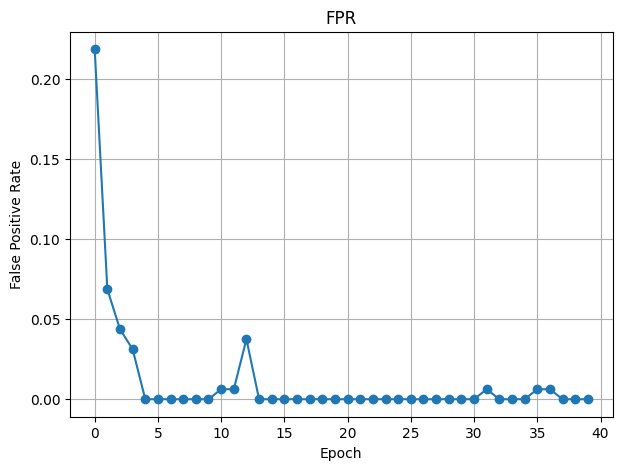

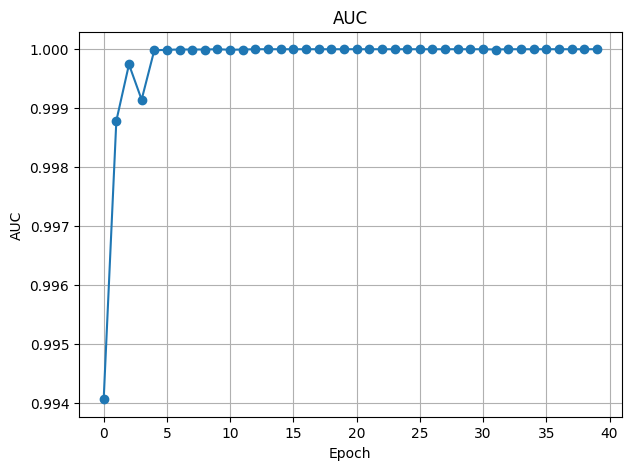

In [29]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ======================================================
# 1. YOUR MODEL (example LSTM — replace with your own)
# ======================================================
class LSTMSeqClassifier(nn.Module):
    def __init__(self, feature_dim, hidden_dim=128, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=feature_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.3,
            bidirectional=False
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 2)     # 2 classes, raw logits (CrossEntropy)
        )

    def forward(self, x):
        out, (hn, cn) = self.lstm(x)
        last_hidden = hn[-1]     # [batch, hidden_dim]
        return self.fc(last_hidden)


# ============================================
# 2. Initialize model, optimizer, loss
# ============================================
feature_dim = X_train_scaled.shape[2]   # from sliding window shape
model = LSTMSeqClassifier(feature_dim).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


# ======================================================
# 3. Validation Function (returns all metrics)
# ======================================================
def evaluate(model, loader, criterion, device):
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    losses = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.long().to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            losses.append(loss.item())

            # Softmax prob for class 1
            proba = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            pred = np.argmax(logits.cpu().numpy(), axis=1)

            y_true.extend(y_batch.cpu().numpy())
            y_pred.extend(pred)
            y_prob.extend(proba)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    fpr = fp / (fp + tn)

    try:
        auc = roc_auc_score(y_true, y_prob)
    except:
        auc = 0.0

    return np.mean(losses), acc, prec, rec, f1, fpr, auc


# ======================================================
# 4. Training Loop with full metric tracking
# ======================================================
EPOCHS = 40
history = {
    "train_loss": [],
    "val_loss": [],
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "fpr": [],
    "auc": []
}

for epoch in range(EPOCHS):
    model.train()
    train_losses = []

    for X_batch, y_batch in tqdm(train_loader, leave=False):
        X_batch = X_batch.to(device)
        y_batch = y_batch.long().to(device)

        optimizer.zero_grad()

        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

    avg_train_loss = np.mean(train_losses)

    # ---- Validation ----
    val_loss, acc, prec, rec, f1, fpr, auc = evaluate(
        model, test_loader, criterion, device
    )

    # Save metrics
    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(val_loss)
    history["accuracy"].append(acc)
    history["precision"].append(prec)
    history["recall"].append(rec)
    history["f1"].append(f1)
    history["fpr"].append(fpr)
    history["auc"].append(auc)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Loss: {avg_train_loss:.4f} | Val Loss: {val_loss:.4f} | "
        f"Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | "
        f"F1: {f1:.4f} | FPR: {fpr:.4f} | AUC: {auc:.4f}"
    )


# ======================================================
# 5. Plot All Curves
# ======================================================
def plot_metric(name, ylabel):
    plt.figure(figsize=(7,5))
    plt.plot(history[name], marker='o')
    plt.title(name.upper())
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.show()

plot_metric("train_loss", "Loss")
plot_metric("val_loss", "Loss")
plot_metric("accuracy", "Accuracy")
plot_metric("precision", "Precision")
plot_metric("recall", "Recall")
plot_metric("f1", "F1 Score")
plot_metric("fpr", "False Positive Rate")
plot_metric("auc", "AUC")

In [30]:
min_values = scaler.data_min_.tolist()
max_values = scaler.data_max_.tolist()

In [31]:
import json

# Create a dictionary to hold the parameters
scaling_data = {
    "feature_min": min_values,
    "feature_max": max_values
}

# Define the output file name
output_file = "scaling_parameters_lstm.json"

# Save the dictionary to a JSON file
try:
    with open(output_file, 'w') as f:
        # Use indent=4 for clean, human-readable formatting
        json.dump(scaling_data, f, indent=4)
    print(f"Successfully saved scaling parameters to {output_file}")
    print("\nExample content (first 5 features shown):")
    # Print the beginning of the JSON for verification
    print(json.dumps(scaling_data, indent=4)[:400] + "...")

except Exception as e:
    print(f"An error occurred: {e}")

Successfully saved scaling parameters to scaling_parameters_lstm.json

Example content (first 5 features shown):
{
    "feature_min": [
        -1.0,
        -1.0,
        -1.0,
        -1.0,
        -1.0,
        -1.0,
        -1.0,
        -1.0,
        -1.0,
        -1.0,
        -1.0,
        -1.0,
        -1.0,
        -1.0,
        -1.0,
        -1.0,
        -1.0,
        -1.0,
        -1.0,
        -1.0,
        -1.0,
        -1.0,
        -1.0,
        -1.0,
        -1.0,
        -1.0,
        -1.0,...


In [32]:
# ======================================================
# Save PyTorch Model Weights (.pth file)
# ======================================================
model_save_path = "fbsdetector_lstm.pth"

# Move model to CPU before saving (best practice for portability)
model.to("cpu")

# Save model state dict
torch.save(model.state_dict(), model_save_path)
print(f"Model weights saved to: {model_save_path}")

# Verify the saved file
import os
file_size_mb = os.path.getsize(model_save_path) / (1024 * 1024)
print(f"Model file size: {file_size_mb:.2f} MB")

Model weights saved to: fbsdetector_lstm.pth
Model file size: 3.54 MB


In [33]:
import torch
from torch.export import export
from executorch.exir import to_edge_transform_and_lower

# --- Configuration (Matching your data shapes) ---
SEQUENCE_LENGTH = 20
FEATURE_DIM = 1408
OUTPUT_PTE_FILE = "fbsdetector_lstm_generic_arm64.pte"

print("--- Starting ExecuTorch Export for Generic ARM64 (Core Kernels) ---")

# 1. Prepare the Model
# Always set to evaluation mode and move to CPU (standard practice)
model.to("cpu")
model.eval()

# 2. Create Example Inputs
# Shape: (Batch_Size, Sequence_Length, Features) -> (1, 20, 1408)
example_inputs = (torch.randn(1, SEQUENCE_LENGTH, FEATURE_DIM),)

try:
    # 3. Export (Capture the Graph)
    print("Capturing model graph...")
    exported_program = export(model, example_inputs)

    # 4. Lower to Portable Kernels
    # By passing an empty list to 'partitioner', the graph is not delegated 
    # to any specific backend (like XNNPACK or Ethos-U), ensuring the core 
    # ExecuTorch C++ implementations handle all operations.
    print("Lowering to core ExecuTorch kernels...")
    edge_program = to_edge_transform_and_lower(
        exported_program,
        partitioner=[]  # <--- No specific backend delegate is chosen.
    )

    # 5. Convert to ExecuTorch Program and Save
    executorch_program = edge_program.to_executorch()

    with open(OUTPUT_PTE_FILE, "wb") as f:
        f.write(executorch_program.buffer)

    print(f"✅ Success! ExecuTorch file saved to: {OUTPUT_PTE_FILE}")

except Exception as e:
    print(f"❌ Export failed: {e}")

--- Starting ExecuTorch Export for Generic ARM64 (Core Kernels) ---
Capturing model graph...
Lowering to core ExecuTorch kernels...
✅ Success! ExecuTorch file saved to: fbsdetector_lstm_generic_arm64.pte
